In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [57]:
plt.rcParams.update({
    "font.size": 14,            # default text size
    "axes.labelsize": 14,       # x/y labels
    "axes.labelweight": "normal",
    "xtick.labelsize": 10,      # x tick labels
    "ytick.labelsize": 10,      # y tick labels
    "legend.fontsize": 12,      # legend text
    "lines.linewidth": 1        # thicker lines
})

Assumptions

steady incompressible (turbulent?)



In [58]:
measurement_data = np.loadtxt("data.txt")
t, p1, p2 = measurement_data[:,0], measurement_data[:,1], measurement_data[:,2]

L = 9
D = 0.1
f = 0.02  # friction factor
R_specific = 286.9  # J /(kg*K)  for dry air
p_atmospheric = 99700  # Pa
Temperature = 26 + 273.15  # Kelvin
rho = p_atmospheric / (R_specific * Temperature)
print(rho)

1.1616508188327486


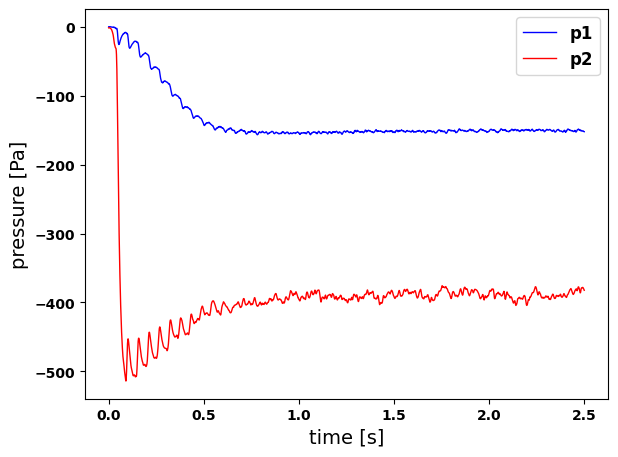

In [59]:
fig, ax = plt.subplots()

#for tick in ax.get_xticklabels() + ax.get_yticklabels():
#    tick.set_fontweight("bold")

plt.plot(t, p1, label="p1", c="b", )
plt.plot(t, p2, label="p2", c="r")
plt.xlabel("time [s]")
plt.ylabel("pressure [Pa]")
plt.legend()
plt.tight_layout()
plt.savefig("pressure_data.pdf", dpi=300)

Estimate V(t) using p_1 mean speed

simple bernoulli:

In [60]:
v_simple = np.sqrt(-2*p1 / (rho))

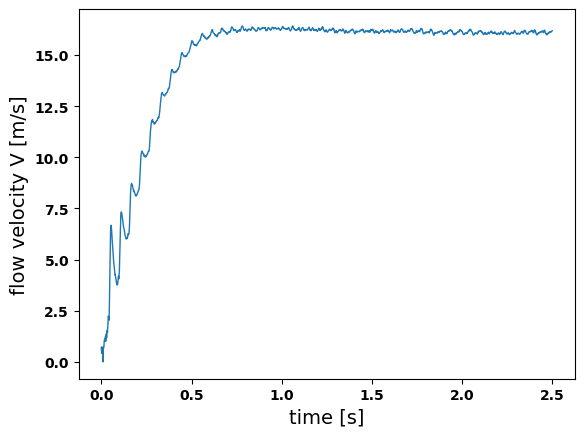

In [ ]:
plt.figure()
plt.plot(t, v_simple, label="simple")
plt.xlabel("time [s]")
plt.ylabel("flow velocity V [m/s]")

Find differential equation and solve

In [71]:
p_2 = -400
L2 = 8.8

In [75]:
def dydt(t, y):
    return (-y**2*rho/2 - p_2 - f * L2/D * (rho*y**2)/2)/(rho*L2)

In [76]:
y0 = [0]

t_span = (0, 2.5)

solution = solve_ivp(dydt, t_span, y0, t_eval=np.linspace(t_span[0], t_span[1], 100))

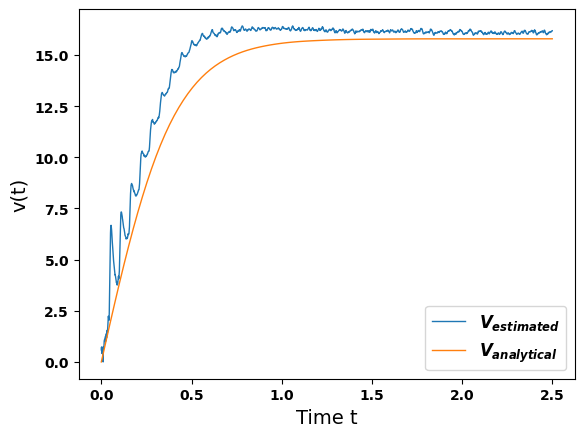

In [ ]:
plt.plot(t, v_simple, label=r"$V_{estimated}$")
plt.plot(solution.t, solution.y[0], label=r"$V_{analytical}$")
plt.xlabel('t [s]')
plt.ylabel('V(t) [m/s]')
plt.legend()
plt.savefig("velocities.pdf", dpi=300)